# S4/S5 · AndinaLog · Notebook 3 · Interpretación de telemetría IoT

Este notebook **solo lee** `andinalog_iot_telemetry_silver.csv`, generado por el notebook 2 después del diagnóstico actualizado del notebook 1. Calcula estadísticas descriptivas, muestra gráficos y redacta una síntesis automática con las cifras de la ejecución. No corrige datos, no modifica Silver y no exporta archivos.

Las banderas `desviacion_termica_flag` y `desviacion_proximos_60min_flag` se interpretan como indicadores presentes en el dataset. Sin conocer sus reglas de generación ni las temperaturas objetivo por producto, el notebook no redefine una desviación ni evalúa la precisión de la bandera de próximos 60 minutos. Las diferencias observadas no prueban causas.


## 1 · Carga local o desde Drive

En local, ejecuta el notebook desde cualquier carpeta del repositorio. En Colab, ajusta `RUTA_PROYECTO_DRIVE` a la carpeta que contiene `S4/`. Las fechas se agrupan tal como están escritas en el CSV; no se les asigna una zona horaria que no está documentada.


In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # "auto", "local" o "drive"
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
NOMBRE_SILVER = "andinalog_iot_telemetry_silver.csv"
COLUMNAS_SILVER = [
    "timestamp", "viaje_id", "order_id", "camion_id", "producto_id",
    "temperatura_cabina_c", "temp_unit", "humedad_cabina_pct",
    "desviacion_termica_flag", "desviacion_proximos_60min_flag",
]

def encontrar_raiz_local():
    for carpeta in [Path.cwd(), *Path.cwd().parents]:
        if (carpeta / "S4" / "andinalog_iot_telemetry" / "notebook2" / "salidas" / NOMBRE_SILVER).is_file():
            return carpeta
    raise FileNotFoundError("No se encontró Silver. Ejecuta dentro del proyecto después de los notebook 1 y 2.")

def obtener_ruta_silver():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        raiz = Path(RUTA_PROYECTO_DRIVE)
    elif entorno == "local":
        raiz = encontrar_raiz_local()
    else:
        raise ValueError("ENTORNO debe ser 'auto', 'local' o 'drive'")
    ruta = raiz / "S4" / "andinalog_iot_telemetry" / "notebook2" / "salidas" / NOMBRE_SILVER
    if not ruta.is_file():
        raise FileNotFoundError(f"No se encontró Silver: {ruta}")
    return ruta

RUTA_SILVER = obtener_ruta_silver()
print("Silver:", RUTA_SILVER)


Silver: c:\Users\remrodri\Github\practicasNotebookColab\S4\andinalog_iot_telemetry\notebook2\salidas\andinalog_iot_telemetry_silver.csv


## 2 · Contrato de entrada

Esta comprobación impide interpretar un Silver antiguo que todavía contenga `-999`. Si falla, vuelve a ejecutar el notebook 1 corregido y luego el notebook 2. Las conversiones de tipo siguientes se hacen solo en memoria para el análisis.


In [3]:
df_silver_raw = pd.read_csv(RUTA_SILVER, dtype="string", encoding="utf-8-sig", keep_default_na=False)
if list(df_silver_raw.columns) != COLUMNAS_SILVER:
    raise ValueError(f"Esquema Silver inesperado: {list(df_silver_raw.columns)}")
if df_silver_raw.empty:
    raise ValueError("Silver está vacío")
if df_silver_raw[COLUMNAS_SILVER].eq("").any().any():
    raise ValueError("Silver contiene valores vacíos")
if not df_silver_raw["temp_unit"].eq("C").all():
    raise ValueError("Silver debe expresar toda la temperatura preparada en Celsius")

df = df_silver_raw.copy(deep=True)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")
for columna in ["temperatura_cabina_c", "humedad_cabina_pct", "desviacion_termica_flag", "desviacion_proximos_60min_flag"]:
    df[columna] = pd.to_numeric(df[columna], errors="raise")
if df[["temperatura_cabina_c", "humedad_cabina_pct"]].isna().any().any():
    raise ValueError("Silver contiene mediciones no numéricas")
if df["temperatura_cabina_c"].eq(-999).any() or df["temperatura_cabina_c"].lt(-273.15).any():
    total = int(df["temperatura_cabina_c"].eq(-999).sum())
    raise ValueError(f"Silver contiene {total} temperaturas -999 u otra temperatura físicamente imposible. Reejecuta los notebook 1 y 2 corregidos.")
if not df["humedad_cabina_pct"].between(0, 100).all():
    raise ValueError("Silver contiene humedad fuera de 0 a 100 %")
for columna in ["desviacion_termica_flag", "desviacion_proximos_60min_flag"]:
    if not df[columna].isin([0, 1]).all():
        raise ValueError(f"Silver contiene una bandera inválida en {columna}")
if df.duplicated(["viaje_id", "timestamp"]).any():
    raise ValueError("Silver contiene claves viaje_id + timestamp duplicadas")

print(f"Lecturas utilizables: {len(df):,}")
print(f"Viajes: {df['viaje_id'].nunique():,}; camiones: {df['camion_id'].nunique():,}; productos: {df['producto_id'].nunique():,}")
print("Periodo registrado:", df["timestamp"].min(), "a", df["timestamp"].max())


Lecturas utilizables: 28,475
Viajes: 1,200; camiones: 50; productos: 60
Periodo registrado: 2026-08-01 01:11:00 a 2026-08-31 10:25:00


## 3 · Resumen general

Las cifras de desviación son frecuencias de las banderas existentes, no un diagnóstico nuevo. Las lecturas repetidas dentro de un viaje no son observaciones independientes de un viaje; por eso se muestran métricas por lectura **y** por viaje.


In [4]:
mediciones = df[["temperatura_cabina_c", "humedad_cabina_pct"]].describe(percentiles=[0.25, 0.5, 0.75]).T
mediciones = mediciones.rename(columns={"count":"lecturas","mean":"media","std":"desv_est","min":"minimo","25%":"p25","50%":"mediana","75%":"p75","max":"maximo"})
mediciones = mediciones[["lecturas","media","mediana","desv_est","minimo","p25","p75","maximo"]]
display(mediciones.round(2))

resumen_banderas = pd.DataFrame([
    {"indicador":"Desviación térmica actual", "lecturas_con_flag":int(df["desviacion_termica_flag"].sum()), "total_lecturas":len(df), "porcentaje_lecturas":100*df["desviacion_termica_flag"].mean()},
    {"indicador":"Desviación próximos 60 min", "lecturas_con_flag":int(df["desviacion_proximos_60min_flag"].sum()), "total_lecturas":len(df), "porcentaje_lecturas":100*df["desviacion_proximos_60min_flag"].mean()},
])
display(resumen_banderas.round(2))


,lecturas,media,mediana,desv_est,minimo,p25,p75,maximo
temperatura_cabina_c,28475.0,8.85,17.56,14.45,-21.18,3.48,20.27,30.59
humedad_cabina_pct,28475.0,60.03,57.0,15.24,21.4,47.2,73.6,100.0


,indicador,lecturas_con_flag,total_lecturas,porcentaje_lecturas
0,Desviación térmica actual,767,28475,2.69
1,Desviación próximos 60 min,1113,28475,3.91


## 4 · Lectura por viaje

Se resume si cada viaje tiene **al menos una** lectura marcada. Esto reduce la confusión entre “773 lecturas marcadas” y “773 viajes afectados”. No se atribuye el problema a un camión concreto, ya que algunas claves de viaje incluyen más de un `camion_id` en los datos.


In [5]:
tabla_viajes = df.groupby("viaje_id", sort=True).agg(
    lecturas=("timestamp", "size"),
    alguna_desviacion_actual=("desviacion_termica_flag", "max"),
    alguna_desviacion_proximos_60min=("desviacion_proximos_60min_flag", "max"),
    camiones_distintos=("camion_id", "nunique"),
)
resumen_viajes = pd.DataFrame([
    {"indicador":"Al menos una desviación térmica actual", "viajes_con_flag":int(tabla_viajes["alguna_desviacion_actual"].sum()), "total_viajes":len(tabla_viajes), "porcentaje_viajes":100*tabla_viajes["alguna_desviacion_actual"].mean()},
    {"indicador":"Al menos una bandera de próximos 60 min", "viajes_con_flag":int(tabla_viajes["alguna_desviacion_proximos_60min"].sum()), "total_viajes":len(tabla_viajes), "porcentaje_viajes":100*tabla_viajes["alguna_desviacion_proximos_60min"].mean()},
])
display(resumen_viajes.round(2))
print("Lecturas por viaje (mínimo, mediana, máximo):", int(tabla_viajes["lecturas"].min()), float(tabla_viajes["lecturas"].median()), int(tabla_viajes["lecturas"].max()))
print("Viajes con más de un camion_id registrado:", int(tabla_viajes["camiones_distintos"].gt(1).sum()))


,indicador,viajes_con_flag,total_viajes,porcentaje_viajes
0,Al menos una desviación térmica actual,317,1200,26.42
1,Al menos una bandera de próximos 60 min,317,1200,26.42


Lecturas por viaje (mínimo, mediana, máximo): 21 24.0 24
Viajes con más de un camion_id registrado: 49


## 5 · Evolución diaria observada

La tasa diaria usa lecturas como denominador. Cada fecha se interpreta tal como aparece en Silver, sin convertir zonas horarias ni asumir que el volumen de lecturas sea constante. Una tasa alta orienta una revisión, pero no prueba una causa.


In [6]:
df["fecha_registrada"] = df["timestamp"].dt.date
tabla_diaria = df.groupby("fecha_registrada", sort=True).agg(
    lecturas=("timestamp", "size"),
    temperatura_mediana_c=("temperatura_cabina_c", "median"),
    humedad_mediana_pct=("humedad_cabina_pct", "median"),
    desviaciones_actuales=("desviacion_termica_flag", "sum"),
    banderas_proximos_60min=("desviacion_proximos_60min_flag", "sum"),
)
tabla_diaria["pct_desviacion_actual"] = 100*tabla_diaria["desviaciones_actuales"]/tabla_diaria["lecturas"]
tabla_diaria["pct_proximos_60min"] = 100*tabla_diaria["banderas_proximos_60min"]/tabla_diaria["lecturas"]
assert tabla_diaria["lecturas"].sum() == len(df)
display(tabla_diaria.round(2))


,lecturas,temperatura_mediana_c,humedad_mediana_pct,desviaciones_actuales,banderas_proximos_60min,pct_desviacion_actual,pct_proximos_60min
fecha_registrada,,,,,,,
2026-08-01,598,18.34,54.85,11,16,1.84,2.68
2026-08-02,930,18.49,54.3,25,34,2.69,3.66
2026-08-03,1118,17.82,57.2,23,31,2.06,2.77
2026-08-04,897,5.31,61.7,19,28,2.12,3.12
2026-08-05,1252,18.57,53.85,58,88,4.63,7.03
2026-08-06,781,18.43,54.6,6,7,0.77,0.9
2026-08-07,936,5.89,61.45,19,27,2.03,2.88
2026-08-08,1092,17.27,57.6,20,30,1.83,2.75
2026-08-09,807,5.07,62.6,26,37,3.22,4.58


## 6 · Gráficos

Las distribuciones muestran temperatura y humedad; las series diarias muestran tasas junto al número de lecturas. No se dibujan umbrales térmicos por producto porque Silver no contiene las temperaturas objetivo.


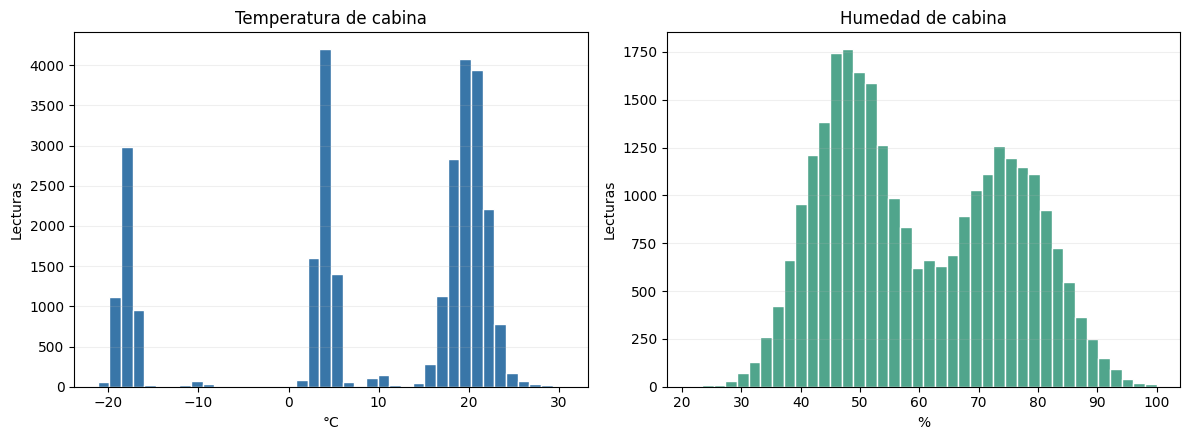

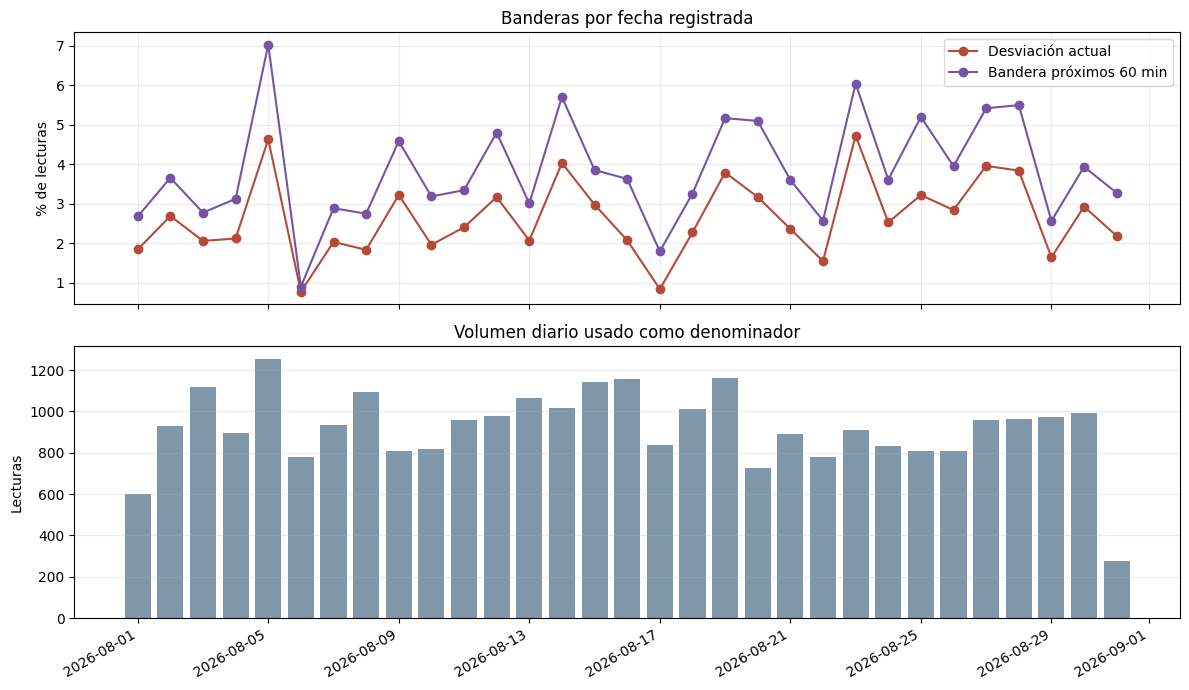

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["temperatura_cabina_c"], bins=40, color="#3976A8", edgecolor="white")
axes[0].set(title="Temperatura de cabina", xlabel="°C", ylabel="Lecturas")
axes[1].hist(df["humedad_cabina_pct"], bins=40, color="#50A58C", edgecolor="white")
axes[1].set(title="Humedad de cabina", xlabel="%", ylabel="Lecturas")
for ax in axes: ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
dias = pd.to_datetime(tabla_diaria.index)
axes[0].plot(dias, tabla_diaria["pct_desviacion_actual"], marker="o", label="Desviación actual", color="#B44A3A")
axes[0].plot(dias, tabla_diaria["pct_proximos_60min"], marker="o", label="Bandera próximos 60 min", color="#7455A5")
axes[0].set_ylabel("% de lecturas")
axes[0].set_title("Banderas por fecha registrada")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].bar(dias, tabla_diaria["lecturas"], color="#8097AA", width=0.8)
axes[1].set_ylabel("Lecturas")
axes[1].set_title("Volumen diario usado como denominador")
axes[1].grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 7 · Relación entre las dos banderas

La tabla cruza las banderas **en la misma lectura**. No mide si una predicción a 60 minutos se cumplió: para eso haría falta una definición formal del objetivo, emparejar cada lectura con una observación futura y acordar cómo tratar viajes sin seguimiento completo.


In [8]:
cruce_banderas = pd.crosstab(
    df["desviacion_termica_flag"], df["desviacion_proximos_60min_flag"],
    rownames=["Desviación actual"], colnames=["Bandera próximos 60 min"],
).reindex(index=[0,1], columns=[0,1], fill_value=0)
display(cruce_banderas)
assert cruce_banderas.to_numpy().sum() == len(df)


Bandera próximos 60 min,0,1
Desviación actual,,
0,27006,702
1,356,411


## 8 · Síntesis descriptiva automática

El texto se calcula con el Silver de esta ejecución. Sirve como punto de partida para la interpretación; no convierte una asociación en una explicación causal.


In [9]:
def redactar_sintesis(datos, viajes, diaria, banderas):
    n = len(datos)
    v = len(viajes)
    actual = int(datos["desviacion_termica_flag"].sum())
    futura = int(datos["desviacion_proximos_60min_flag"].sum())
    viajes_actual = int(viajes["alguna_desviacion_actual"].sum())
    dia_max = diaria["pct_desviacion_actual"].idxmax()
    dia = diaria.loc[dia_max]
    lineas = [
        f"ALCANCE: {n:,} lecturas utilizables de {v:,} viajes, registradas en {len(diaria)} fechas. "
        "Las filas en cuarentena no forman parte de estos cálculos.",
        f"MEDICIONES: temperatura mediana {datos['temperatura_cabina_c'].median():.2f} °C "
        f"y humedad mediana {datos['humedad_cabina_pct'].median():.2f} %.",
        f"BANDERAS POR LECTURA: desviación actual en {actual:,} de {n:,} lecturas "
        f"({100*actual/n:.2f} %); próximos 60 minutos en {futura:,} de {n:,} "
        f"({100*futura/n:.2f} %).",
        f"POR VIAJE: {viajes_actual:,} de {v:,} viajes ({100*viajes_actual/v:.2f} %) "
        "tienen al menos una lectura con desviación actual.",
        f"FECHA A REVISAR: {dia_max} tiene la mayor proporción diaria observada de desviación actual: "
        f"{int(dia['desviaciones_actuales'])} de {int(dia['lecturas'])} lecturas "
        f"({dia['pct_desviacion_actual']:.2f} %). El volumen diario y la composición de viajes "
        "deben revisarse antes de compararlo con otras fechas.",
        "LÍMITE: las banderas disponibles no prueban la causa de una desviación ni permiten "
        "evaluar la precisión de la alerta de próximos 60 minutos.",
    ]
    return "\n\n".join(lineas)

sintesis_descriptiva = redactar_sintesis(df, tabla_viajes, tabla_diaria, resumen_banderas)
print(sintesis_descriptiva)


ALCANCE: 28,475 lecturas utilizables de 1,200 viajes, registradas en 31 fechas. Las filas en cuarentena no forman parte de estos cálculos.

MEDICIONES: temperatura mediana 17.56 °C y humedad mediana 57.00 %.

BANDERAS POR LECTURA: desviación actual en 767 de 28,475 lecturas (2.69 %); próximos 60 minutos en 1,113 de 28,475 (3.91 %).

POR VIAJE: 317 de 1,200 viajes (26.42 %) tienen al menos una lectura con desviación actual.

FECHA A REVISAR: 2026-08-23 tiene la mayor proporción diaria observada de desviación actual: 43 de 910 lecturas (4.73 %). El volumen diario y la composición de viajes deben revisarse antes de compararlo con otras fechas.

LÍMITE: las banderas disponibles no prueban la causa de una desviación ni permiten evaluar la precisión de la alerta de próximos 60 minutos.


## 9 · Guía de interpretación

Después de ejecutar, redacta tres hallazgos. Para cada uno indica: **observación**, **cifra o gráfico que la respalda**, **decisión que podría orientar** y **qué no se puede concluir aún**.

1. ¿Qué muestran la mediana y la distribución de temperatura y humedad? No supongas que un valor es correcto para todos los productos: faltan sus rangos objetivo.
2. ¿Cómo cambia la lectura cuando pasas de porcentajes por lectura a porcentajes por viaje?
3. ¿Qué fecha merece revisión y cuántas lecturas la sustentan? Revisa el volumen y la composición antes de atribuir una causa.
4. ¿Qué evidencia adicional haría falta para comprobar una alerta de próximos 60 minutos?

**Limitaciones:** Silver solo incluye filas utilizables. No dispone de umbrales térmicos por producto, motivo de alarma, contexto de ruta, zona horaria documentada ni información suficiente para atribuir fallas a un camión o conductor. Este notebook no lee cuarentena ni estima cómo cambiarían los resultados si esas filas se resolvieran.


## 10 · Validaciones finales

Las agregaciones deben cuadrar con Silver. El notebook no escribe ni reemplaza archivos.


In [10]:
assert len(df) == len(df_silver_raw)
assert "fecha_registrada" not in df_silver_raw.columns
assert tabla_diaria["lecturas"].sum() == len(df)
assert tabla_viajes["lecturas"].sum() == len(df)
assert resumen_banderas["total_lecturas"].eq(len(df)).all()
assert resumen_viajes["total_viajes"].eq(len(tabla_viajes)).all()
assert cruce_banderas.to_numpy().sum() == len(df)
assert f"{len(df):,} lecturas utilizables" in sintesis_descriptiva
print("Validaciones correctas. Silver no fue modificado.")


Validaciones correctas. Silver no fue modificado.
